<!-- config-banner -->
# 06 — Time evolution of the adjoint sensitivities & interactive animations

**Question.** How do the adjoint sensitivity fields evolve over the 5-yr
reverse sweep — and, for the four members whose adjoints blow up, *when* and
*how* (at what rate, seeded where) do they depart from the reference? This
notebook also produces the suite's four interactive HTML animations.

**Reads** (under `/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/`):

- `cache/timeseries_stats.nc` — wet-cell RMS / finite-fraction of every ADJ\*
  dump of all nine runs (366 dumps × 11 variables), built by `build_cache.py`,
- `cache/member_metrics_time.nc` — member-vs-reference pattern metrics at all
  dump iterations,
- `cache/run_table.csv` + `cache/stable_runs.npy` — run health and the
  stable/blown classification,
- raw `ADJtheta` / `ADJdiffkr` dumps of runs REF (30995), M3 (31005) and
  M5 (31007) for the animation frames — always **one file at a time** (~1.5 MB
  each); no full 3-D time series is ever held in memory.

**Writes** figures to `figures/06_time_evolution_and_animations/`, four
self-contained interactive HTML animations to `animations/`, and summary CSVs
(the handoff to notebook 07) to `stats/` — all on scratch, nothing into the
repository.

Run table and suite reading order: see `README.md` in this directory.
Analysis date: **2026-08-30**.

In [1]:
import warnings
import time as _time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ensemble_common as ec

ec.setup_style()
NB_STEM = "06_time_evolution_and_animations"
ec.STATS_ROOT.mkdir(parents=True, exist_ok=True)
ec.ANIM_ROOT.mkdir(parents=True, exist_ok=True)

# Blown-up members reach RMS ~1e42 and M4 carries inf/NaN; logs and ratios of
# those values are taken deliberately below (log-axis plots, log-linear fits),
# so the numpy overflow/invalid warnings are silenced to keep outputs readable.
warnings.filterwarnings("ignore", message="overflow")
warnings.filterwarnings("ignore", message="invalid value")
warnings.filterwarnings("ignore", message="divide by zero")
np.seterr(over="ignore", invalid="ignore", divide="ignore")

ts = ec.open_cache("timeseries_stats.nc")        # (run, var, time)
mm = ec.open_cache("member_metrics_time.nc")     # (member, var, time, weighting)
run_table = pd.read_csv(ec.CACHE_DIR / "run_table.csv").set_index("run")
stable_runs = [str(r) for r in np.load(ec.CACHE_DIR / "stable_runs.npy")]
STABLE = [m for m in ec.MEMBERS if m in stable_runs]
BLOWN = [m for m in ec.MEMBERS if m not in stable_runs]
assert STABLE == ["M2", "M3", "M6"] and BLOWN == ["M1", "M4", "M5", "M7"]

# The cached time axis is the FORWARD-model dump iteration: index 0 = window
# start = lead 5 yr (the fully accumulated sensitivity), last index = lead
# 0.014 yr.  ORD re-sorts everything into increasing lead = the order in
# which the adjoint actually computed the dumps (the reverse sweep).
assert int(ts.time[0]) == ec.NITER0 and ts.time.size == 366
assert np.array_equal(ts.time.values, mm.time.values)
LEAD = ts.lead_years.values
ORD = np.argsort(LEAD)
LO = LEAD[ORD]                       # lead [yr], increasing (adjoint order)
DAYS = LO * 366.0                    # lead in model days (366-d year)

g = ec.read_grid()
print(f"{ts.time.size} dumps per run, lead {LO[0]:.4f} -> {LO[-1]:.1f} yr "
      f"(every {ec.DUMP_STRIDE} steps = 5 d); stable subset {stable_runs}")

366 dumps per run, lead 0.0137 -> 5.0 yr (every 240 steps = 5 d); stable subset ['M2', 'REF', 'M3', 'M6']


## 1. Method — time conventions, and what an adjoint "blow-up" is

**Reversed time.** `ADJ*` dump files are numbered by *forward-model*
iteration, but the adjoint integrates backwards: the dump with the **largest**
iteration number (end of the window) is the **first** one computed, and the
dump at the window start (iteration 3 162 240) is the last — it holds the
fully accumulated 5-yr sensitivity. Everything in this notebook is therefore
plotted against **lead time**

$$L(i) \;=\; \frac{3\,250\,080 - i}{17\,568}\ \text{yr},$$

the time remaining before the cost-window end at iteration $i$ (17 568 steps
= one 366-day model year at $\Delta t = 1800$ s). The dump at lead $L$
answers: *how does the terminal-month transport index $J$ respond to a
perturbation applied $L$ years before the end of the window?* On every
lead-time axis below, the reverse sweep proceeds **left → right** (from
lead 0.014 yr to lead 5 yr); forward-model time runs right → left.

**What blows up, exactly.** The adjoint model is the *transposed
linearisation* of MITgcm, integrated backwards along the stored forward
trajectory. A "blow-up" is unbounded growth of the adjoint (co-state) fields
— an instability of the **linearised dynamics around that member's own
background trajectory**. The member's forward run is entirely unaffected:
all nine `fc` values are healthy and monotonic in κ (notebook 01), and the
forward monitor series show no anomaly. Only the reverse sweep diverges,
which is why a run can hand back a perfectly good cost value together with a
sensitivity field of RMS $10^{42}$.

**Why this can happen here.** All nine adjoint runs use the *plain* build:
`viscFacInAd` is not set in `data.autodiff`, so the adjoint integrates with
the same viscosity/diffusivity as the forward model (factor 1, no boost).
The repository carries an `adjViscBoost` build + namelist variant
(`viscFacInAd = 10`) precisely because long adjoints of this configuration
can blow up; these runs deliberately do **not** use it, so the ensemble maps
where the plain adjoint's stability boundary lies — and, as shown below, the
boundary is crossed **non-monotonically** in κ.

In [2]:
print("Adjoint window (shared by all nine runs):")
print(f"  nIter0 = {ec.NITER0}  ->  nIterEnd = {ec.NITER_END}   "
      f"({ec.NSTEPS} steps, dT = {ec.DT:.0f} s)")
print(f"  model years {ec.model_year(ec.NITER0):.1f} -> "
      f"{ec.model_year(ec.NITER_END):.1f}; dumps every 5 d -> "
      f"{len(ec.ITERS)} dumps; lead 5.0 yr = fully accumulated sensitivity")

K_ANIM = [2, 14, 24]     # animation depths: near-surface / thermocline / near cost base
print("\nDepth levels used for animations and montages:")
for k in K_ANIM:
    print(f"  k={k:2d}: Z = {g['Z'][k]:7.1f} m")

tab = run_table[["kappa_factor", "fc", "rms_final_ADJtheta",
                 "finite_frac_final_ADJtheta"]].copy()
tab["stable"] = [r in stable_runs for r in tab.index]
print("\nRun classification (stable = final ADJtheta finite everywhere AND "
      "wet RMS within 10x of REF):")
print(tab.to_string(float_format=lambda v: f"{v:.4g}"))

Adjoint window (shared by all nine runs):
  nIter0 = 3162240  ->  nIterEnd = 3250080   (87840 steps, dT = 1800 s)
  model years 2180.0 -> 2185.0; dumps every 5 d -> 366 dumps; lead 5.0 yr = fully accumulated sensitivity

Depth levels used for animations and montages:
  k= 2: Z =   -26.0 m
  k=14: Z =  -231.0 m
  k=24: Z =  -915.4 m

Run classification (stable = final ADJtheta finite everywhere AND wet RMS within 10x of REF):
     kappa_factor     fc  rms_final_ADJtheta  finite_frac_final_ADJtheta  stable
run                                                                             
M1           0.25 0.2141           2.302e+04                           1   False
M2            0.5 0.2598           6.316e-05                           1    True
REF             1  0.331           4.627e-05                           1    True
M3              2 0.2649           3.563e-05                           1    True
M4              4 0.2731           9.101e+37                      0.6267   False
M5  

## 2. Amplitude evolution — wet-RMS vs lead time, and when each member departs

From `timeseries_stats.nc`: the wet-cell RMS of every dump (computed over
*finite* values only, so M4's curve stays plottable after inf/NaN appear —
its finite fraction is tracked separately in §4). Three numbers are computed
per blown member:

- **departure lead** $L_{\rm dep}$: scanning in adjoint computation order
  (increasing lead), the first lead at which the member's ADJtheta RMS is
  ≥ 10× the reference RMS *at the same lead* (NaN counts as departed);
- **e-fold time** from a log-linear fit of $\ln(\mathrm{RMS_{member}} /
  \mathrm{RMS_{REF}})$ vs lead over the divergence phase — from $L_{\rm dep}$
  until the log-ratio first reaches 90 % of its maximum. The fit $R^2$ is
  reported alongside, because (as the plot shows) the growth turns out to be
  **episodic** — long plateaus punctuated by bursts — which a single
  exponential fits poorly;
- **burst e-fold time**: the steepest growth over any 30-d (6-dump) window —
  the instability's growth rate *while it is actually growing*.

The same 10×-REF crossing is also computed for the surface field ADJtaux, to
check whether the 2-D forcing sensitivities depart together with the 3-D
state sensitivities (they are one coupled co-state vector, so they should).

In [3]:
VAR0 = "ADJtheta"
rms_ref = ts["rms"].sel(var=VAR0, run="REF").values[ORD]


def departure_index(ratio):
    # first index (adjoint order) where the ratio is NOT < 10 (catches NaN)
    bad = np.where(~(ratio < 10.0))[0]
    return int(bad[0]) if bad.size else None


rows, DEP_LEAD, DEP_RMS = [], {}, {}
for mem in ec.MEMBERS:
    r = ts["rms"].sel(var=VAR0, run=mem).values[ORD]
    ratio = r / rms_ref
    logr = np.where(np.isfinite(ratio) & (ratio > 0), np.log(ratio), np.nan)
    ff = ts["finite_frac"].sel(var=VAR0, run=mem).values[ORD]
    nonfin = np.where(ff < 1.0)[0]
    first_nonfin = LO[nonfin[0]] if nonfin.size else np.nan
    row = dict(member=mem, kappa_factor=ec.RUNS[mem]["factor"],
               stable=mem in STABLE, final_rms_ratio=ratio[-1],
               min_finite_frac=ff.min(), first_nonfinite_lead_yr=first_nonfin)
    i0 = departure_index(ratio)
    if i0 is not None:
        DEP_LEAD[mem], DEP_RMS[mem] = LO[i0], r[i0]
        # log-linear fit over the divergence phase
        mx = np.nanmax(logr)
        i1 = int(np.where(logr >= 0.9 * mx)[0][0])
        sel = np.arange(i0, i1 + 1)
        sel = sel[np.isfinite(logr[sel])]
        A = np.polyfit(DAYS[sel], logr[sel], 1)
        pred = np.polyval(A, DAYS[sel])
        r2 = 1.0 - (((logr[sel] - pred) ** 2).sum()
                    / ((logr[sel] - logr[sel].mean()) ** 2).sum())
        # steepest 30-d window
        best, bi = -np.inf, 0
        for i in range(len(logr) - 6):
            if np.isfinite(logr[i]) and np.isfinite(logr[i + 6]):
                grow = (logr[i + 6] - logr[i]) / (DAYS[i + 6] - DAYS[i])
                if grow > best:
                    best, bi = grow, i
        row.update(dep_lead_yr=LO[i0], dep_lead_days=DAYS[i0],
                   efold_fit_days=1.0 / A[0], fit_R2=r2,
                   efold_burst_days=1.0 / best,
                   burst_lead_lo_yr=LO[bi], burst_lead_hi_yr=LO[bi + 6])
    rows.append(row)

dep_df = pd.DataFrame(rows).set_index("member")
col_order = ["kappa_factor", "stable", "dep_lead_yr", "dep_lead_days",
             "efold_fit_days", "fit_R2", "efold_burst_days",
             "burst_lead_lo_yr", "burst_lead_hi_yr", "final_rms_ratio",
             "min_finite_frac", "first_nonfinite_lead_yr"]
dep_df = dep_df[col_order]
csvp = ec.STATS_ROOT / "06_blowup_departure_table.csv"
dep_df.to_csv(csvp)
print(f"saved {csvp}\n")
print("Departure / growth-rate table (ADJtheta wet RMS vs REF at equal lead):")
print(dep_df.to_string(float_format=lambda v: f"{v:.4g}"))

# do the 2-D forcing sensitivities depart at the same leads?
taux_ref = ts["rms"].sel(var="ADJtaux", run="REF").values[ORD]
print("\n10x-REF crossing of ADJtaux (2-D) vs ADJtheta (3-D):")
for mem in BLOWN:
    rt = ts["rms"].sel(var="ADJtaux", run=mem).values[ORD] / taux_ref
    i2 = departure_index(rt)
    print(f"  {mem}: ADJtaux departs at lead {LO[i2]:.3f} yr "
          f"(ADJtheta: {DEP_LEAD[mem]:.3f} yr)")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/06_blowup_departure_table.csv

Departure / growth-rate table (ADJtheta wet RMS vs REF at equal lead):
        kappa_factor  stable  dep_lead_yr  dep_lead_days  efold_fit_days  fit_R2  efold_burst_days  burst_lead_lo_yr  burst_lead_hi_yr  final_rms_ratio  min_finite_frac  first_nonfinite_lead_yr
member                                                                                                                                                                                           
M1              0.25   False        2.555            935           133.1  0.2109             3.218             3.497             3.579        4.976e+08                1                      NaN
M2               0.5    True          NaN            NaN             NaN     NaN               NaN               NaN               NaN            1.365                1                      NaN
M3                 2    True          NaN 

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/01_rms_vs_lead_3d.png


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/02_rms_vs_lead_2d.png


PosixPath('/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/02_rms_vs_lead_2d.png')

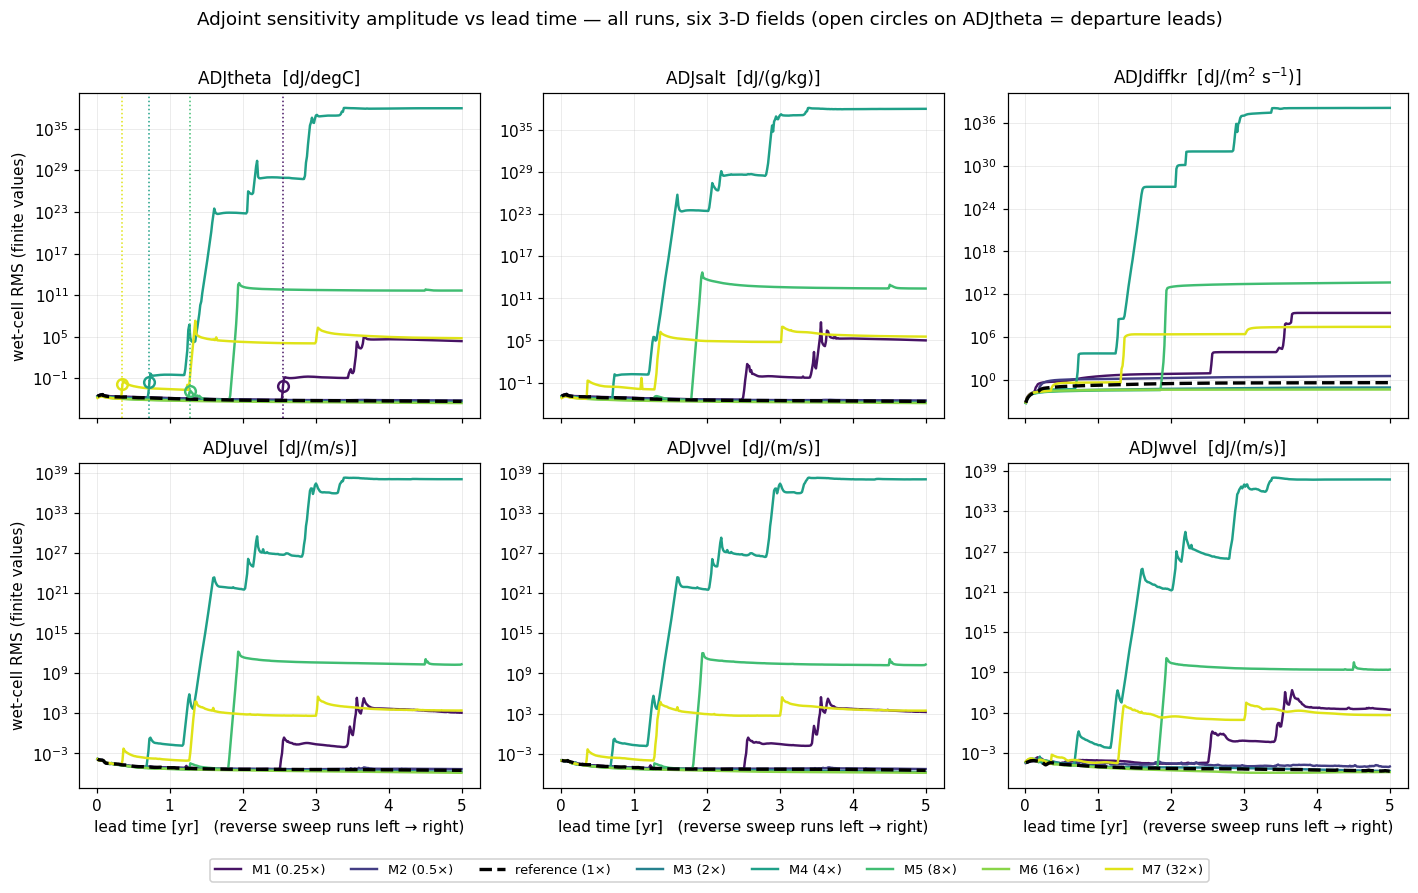

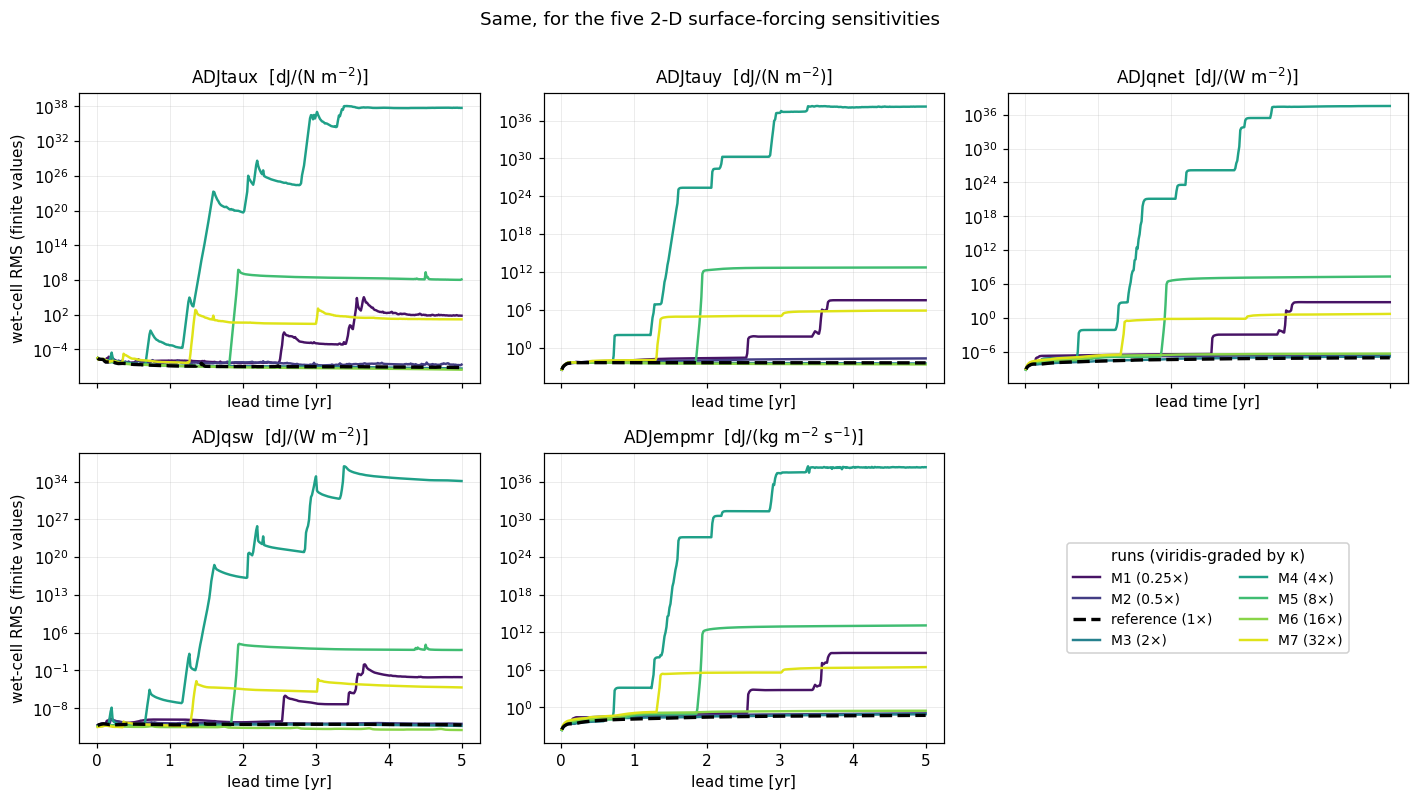

In [4]:
# ---- the money plot: wet RMS vs lead, one panel per 3-D variable ----------
fig, axes = plt.subplots(2, 3, figsize=(13, 7.6), sharex=True)
for ax, v in zip(axes.flat, ec.ADJ_3D):
    for run in ec.RUN_ORDER:
        ax.plot(LO, ts["rms"].sel(var=v, run=run).values[ORD],
                **ec.line_kwargs(run))
    ax.set_yscale("log")
    ax.set_title(f"{v}  [{ec.ADJ_VARS[v]['units']}]")
    if v == "ADJtheta":                      # mark the departure leads
        for mem, Ld in DEP_LEAD.items():
            ax.axvline(Ld, color=ec.member_color(mem), ls=":", lw=1.0)
            ax.plot([Ld], [DEP_RMS[mem]], "o", ms=7, mfc="none",
                    mec=ec.member_color(mem), mew=1.6, zorder=6)
for ax in axes[1]:
    ax.set_xlabel("lead time [yr]   (reverse sweep runs left → right)")
for ax in axes[:, 0]:
    ax.set_ylabel("wet-cell RMS (finite values)")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=8, loc="lower center",
           bbox_to_anchor=(0.5, -0.045), fontsize=8.5)
fig.suptitle("Adjoint sensitivity amplitude vs lead time — all runs, six 3-D "
             "fields (open circles on ADJtheta = departure leads)", y=1.005)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "01_rms_vs_lead_3d")

# ---- same for the five 2-D surface-forcing sensitivities ------------------
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2), sharex=True)
for ax, v in zip(axes.flat, ec.ADJ_2D):
    for run in ec.RUN_ORDER:
        ax.plot(LO, ts["rms"].sel(var=v, run=run).values[ORD],
                **ec.line_kwargs(run))
    ax.set_yscale("log")
    ax.set_title(f"{v}  [{ec.ADJ_VARS[v]['units']}]")
    ax.set_xlabel("lead time [yr]")
axes.flat[0].set_ylabel("wet-cell RMS (finite values)")
axes.flat[3].set_ylabel("wet-cell RMS (finite values)")
axes.flat[-1].axis("off")
axes.flat[-1].legend(handles, labels, loc="center", fontsize=9, ncol=2,
                     title="runs (viridis-graded by κ)")
fig.suptitle("Same, for the five 2-D surface-forcing sensitivities", y=1.005)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "02_rms_vs_lead_2d")

### What the RMS evolution shows

- **Four adjoints blow up, and the ordering is non-monotonic in κ.**
  Departure leads (ADJtheta ≥ 10× REF): **M7 (32×) at 0.36 yr, M4 (4×) at
  0.72 yr, M5 (8×) at 1.28 yr, M1 (0.25×) at 2.56 yr** — while M2 (0.5×),
  M3 (2×) and M6 (16×) never cross the threshold. Neither the departure lead
  nor the final amplitude orders with κ: the mild perturbation 4× ends
  *highest* (RMS ratio ~2×10⁴², with inf/NaN), the extreme 32× saturates
  near 10⁹, and even the *reduced*-κ member 0.25× blows up while 16× does
  not. The stability of the linearised dynamics evidently depends on each
  member's own 10-yr-adjusted background trajectory (stratification/shear
  state), not directly on the κ value — which is also why it cannot be
  "fixed" by choosing κ conservatively.
- **Growth is episodic, not steadily exponential.** The divergence-phase fits
  give e-fold times of 133 d (M1, R²=0.21), 9 d (M4, R²=0.86), 16 d (M5,
  R²=0.29) and 67 d (M7, R²=0.14): except for M4, the low R² reflects
  staircase-like curves — plateaus of months punctuated by bursts. During the
  steepest 30-d burst the e-fold time is **1.0–3.2 days** (M5 1.0, M7 1.4,
  M4 1.7, M1 3.2 d) — roughly one decade of amplitude per 10–15 days, which
  is why the transition from "healthy" to "saturated" looks nearly
  instantaneous at the 5-d dump cadence.
- **The whole co-state departs together.** The 2-D forcing sensitivities
  cross their own 10× threshold within ~0.5 yr of the 3-D ones (M7 0.37 vs
  0.36 yr; M5 1.83 vs 1.28; M1 2.51 vs 2.56; M4's ADJtaux even earlier, 0.21
  vs 0.72 yr) — the blow-up is a property of the adjoint state vector, not of
  any single field.
- **The healthy curves behave as notebook 02 describes:** REF's ADJtheta RMS
  *decays* by ~5× from lead 0 back to lead 5 (sensitivity to θ is largest
  close to the cost window), while ADJdiffkr *accumulates* monotonically with
  lead; the stable members bracket REF within a factor ~2 throughout.

## 3. Structure loss — correlation vs lead, and each member's usable window

Amplitude is only half the story: a member's sensitivity can decorrelate from
the reference long before (or without) its RMS departing. From
`member_metrics_time.nc`, the volume-weighted centered pattern correlation of
ADJtheta (member vs REF at identical dump iterations) is followed across all
366 leads.

The **usable window** is quantified with the same sustained-threshold
statistic notebook 04 used at thresholds 0.9/0.5, here at **c = 0.8** and
**c = 0.5**:

$$L_{\rho \ge c} = \max\{L : \rho(\ell) \ge c\ \ \forall\, \ell \le L\},$$

i.e. how far back from the cost window the member tracks the reference
without *ever* dropping below the threshold. Two caveats on reading it:
(i) for **stable** members a finite $L_{\rho\ge c}$ is *physics* — the κ
signal emerging (their correlation dips mid-lead and **recovers**, notebook
04); (ii) for **blown** members the drop is terminal. The departure leads of
§2 are marked on the plot to separate the two regimes.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/06_usable_window_ADJtheta_volume.csv

Usable windows (sustained volume-weighted ADJtheta correlation), vs the RMS departure lead;
inf = threshold never crossed in the 5-yr window:
        kappa_factor  stable  L_corr080_yr  L_corr080_days  L_corr050_yr  L_corr050_days  dep_lead_days  corr_lead5d  corr_final_lead5yr
member                                                                                                                                  
M1              0.25   False        0.1776              65         2.527             925            935       0.9816            -0.01115
M2               0.5    True        0.2869             105           inf             inf            NaN        0.992               0.818
M3                 2    True        0.3825             140           inf             inf            NaN       0.9961              0.8455
M4                 4   False        0.2322             

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/03_corr_vs_lead_usable_window.png


PosixPath('/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/03_corr_vs_lead_usable_window.png')

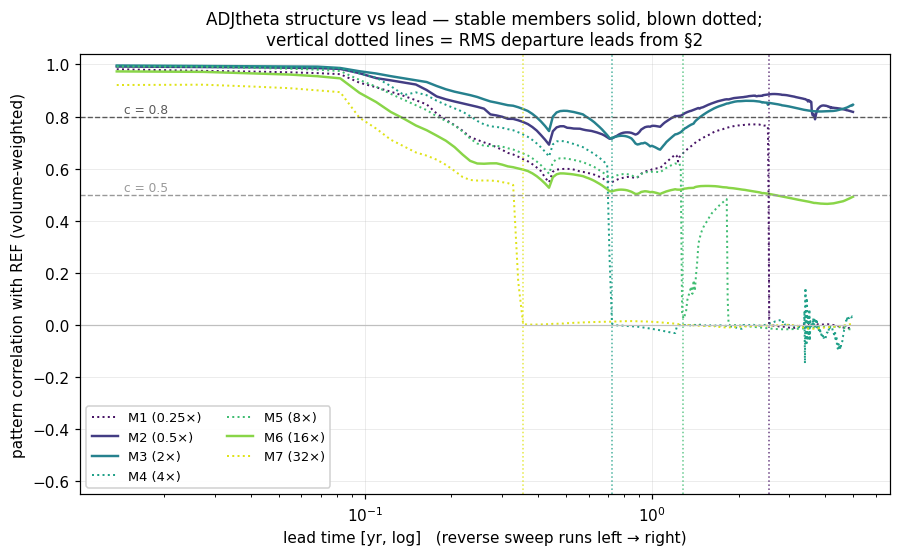

In [5]:
cth = mm["corr"].sel(var="ADJtheta", weighting="volume")


def sustained_lead(cv, th):
    # largest lead L such that cv >= th at every lead <= L (adjoint order)
    bad = np.where(~(cv >= th))[0]
    if bad.size == 0:
        return np.inf
    return 0.0 if bad[0] == 0 else float(LO[bad[0] - 1])


rows = []
for mem in ec.MEMBERS:
    cv = cth.sel(member=mem).values[ORD]
    L08, L05 = sustained_lead(cv, 0.8), sustained_lead(cv, 0.5)
    rows.append(dict(member=mem, kappa_factor=ec.RUNS[mem]["factor"],
                     stable=mem in STABLE,
                     L_corr080_yr=L08, L_corr080_days=366.0 * L08,
                     L_corr050_yr=L05, L_corr050_days=366.0 * L05,
                     dep_lead_days=(366.0 * DEP_LEAD[mem]
                                    if mem in DEP_LEAD else np.nan),
                     corr_lead5d=cv[0], corr_final_lead5yr=cv[-1]))
uw_df = pd.DataFrame(rows).set_index("member")
csvp = ec.STATS_ROOT / "06_usable_window_ADJtheta_volume.csv"
uw_df.to_csv(csvp)
print(f"saved {csvp}\n")
print("Usable windows (sustained volume-weighted ADJtheta correlation), vs "
      "the RMS departure lead;\ninf = threshold never crossed in the 5-yr window:")
print(uw_df.to_string(float_format=lambda v: f"{v:.4g}"))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for mem in ec.MEMBERS:
    kw = ec.line_kwargs(mem)
    if mem in BLOWN:
        kw.update(ls=":", lw=1.3)
    ax.plot(LO, cth.sel(member=mem).values[ORD], **kw)
for mem, Ld in DEP_LEAD.items():
    ax.axvline(Ld, color=ec.member_color(mem), ls=":", lw=1.0, alpha=0.8)
for th, c in [(0.8, "0.35"), (0.5, "0.6")]:
    ax.axhline(th, color=c, lw=0.9, ls="--")
    ax.text(0.0145, th + 0.015, f"c = {th}", fontsize=8, color=c)
ax.axhline(0, color="0.75", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("lead time [yr, log]   (reverse sweep runs left → right)")
ax.set_ylabel("pattern correlation with REF (volume-weighted)")
ax.set_title("ADJtheta structure vs lead — stable members solid, blown dotted;\n"
             "vertical dotted lines = RMS departure leads from §2")
ax.set_ylim(-0.65, 1.04)
ax.legend(ncol=2, loc="lower left", fontsize=8.5)
ec.save_fig(fig, NB_STEM, "03_corr_vs_lead_usable_window")

### Reading the usable windows

- **Every member tracks the reference at short leads** — at the first
  computed dump (lead 5 d) correlations are 0.92–1.00 (`corr_lead5d` column),
  blown members included: close to the cost window the adjoint is dominated
  by the direct (terminal-month) cost forcing, which all members share.
- **The corr ≥ 0.8 windows are short for everyone — 30–140 days** (M7 30 d,
  M6 45 d, M1 = M5 65 d, M4 85 d, M2 105 d, M3 140 d) — and do **not**
  separate stable from blown members: this early drop is mostly the *physical*
  κ response emerging (stable members dip past it and recover to 0.82/0.85 by
  lead 5 yr), plus, for blown members, the first taste of instability.
- **corr ≥ 0.5 does separate the two regimes.** Stable M2/M3 *never* drop
  below 0.5; for the blown members $L_{\rho\ge0.5}$ (M7 120 d, M4 255 d,
  M5 460 d, M1 925 d) sits within one dump (~10 d) of the RMS departure lead —
  structural collapse and amplitude departure are essentially simultaneous.
  M6 again lands in between: it holds 0.5 until 965 d, then degrades without
  ever blowing up (final corr 0.49).
- **Handoff to 07 (training-data implications).** For surrogate training the
  relevant bound is *validity*, not similarity-to-REF: a blown member's
  sensitivities are physically meaningful (finite, ordinary magnitude,
  smoothly diverging from REF for physical reasons) up to its **departure
  lead** — 130 / 265 / 470 / 935 d for M7 / M4 / M5 / M1 — and garbage
  beyond it. Within those windows the *decorrelation from REF is the κ signal
  a surrogate is supposed to learn*, so lead-limited training pairs are
  available from every member; only full-window (5-yr) targets are restricted
  to M2, REF, M3 (and, degraded, M6).

## 4. Loss of finiteness — M4

Blown amplitude and non-finite values are different failure stages: a field
can be enormous yet finite (M1, M5, M7 all stay 100 % finite). Only M4
overflows float range. `finite_frac` (fraction of wet cells with finite
values, recorded per dump by `build_cache.py`) shows when and where.

runs with any non-finite ADJ* values anywhere in the sweep: ['M4']


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/04_finite_frac_M4.png

M4 per-variable finiteness:
           first_nonfinite_lead_yr  min_finite_frac  final_finite_frac
var                                                                   
ADJtheta                     2.951           0.6267             0.6267
ADJsalt                       2.91           0.4739             0.4925
ADJdiffkr                     2.91           0.2357             0.2357
ADJuvel                      2.923           0.2303              0.728
ADJvvel                      2.923           0.1556             0.7594
ADJwvel                      2.923           0.7575             0.9247
ADJtaux                      2.937           0.7332             0.9641
ADJtauy                      2.937          0.05378              0.127
ADJqnet                      3.388           0.9274             0.9274
ADJqsw                       3.388           0.9998  

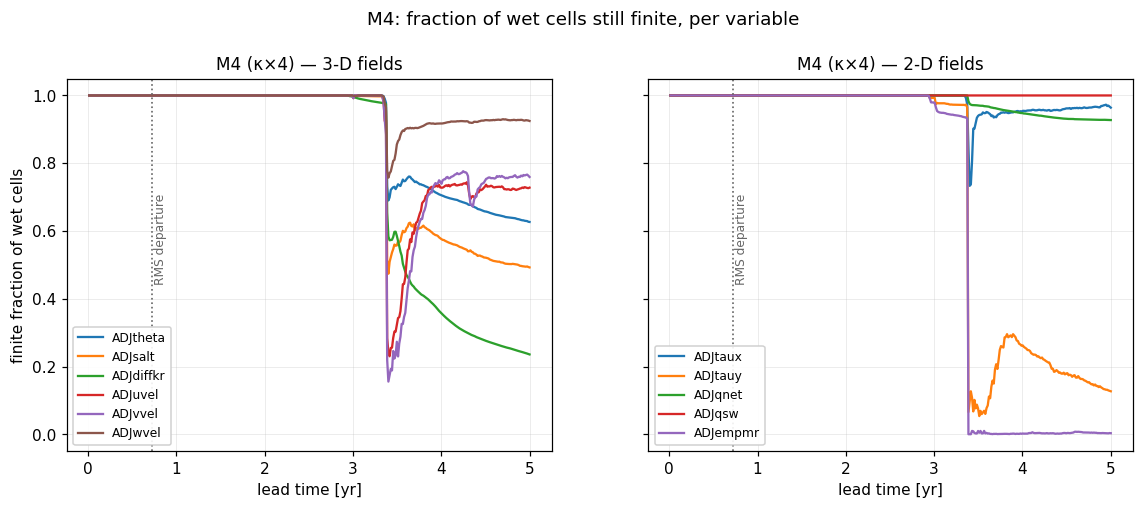

In [6]:
ffall = ts["finite_frac"]
losing = [str(r.values) for r in ts.run
          if float(ffall.sel(run=r).min()) < 1.0]
print("runs with any non-finite ADJ* values anywhere in the sweep:", losing)
assert losing == ["M4"], "expected M4 to be the only run losing finiteness"

colors = [plt.get_cmap("tab10")(i) for i in range(6)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, vlist, ttl in [(axes[0], list(ec.ADJ_3D), "3-D fields"),
                       (axes[1], list(ec.ADJ_2D), "2-D fields")]:
    for v, c in zip(vlist, colors):
        ax.plot(LO, ffall.sel(run="M4", var=v).values[ORD],
                color=c, lw=1.5, label=v)
    ax.axvline(DEP_LEAD["M4"], color="0.4", ls=":", lw=1.1)
    ax.text(DEP_LEAD["M4"] * 1.03, 0.45, "RMS departure", rotation=90,
            fontsize=8, color="0.4")
    ax.set_xlabel("lead time [yr]")
    ax.set_title(f"M4 (κ×4) — {ttl}")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("finite fraction of wet cells")
fig.suptitle("M4: fraction of wet cells still finite, per variable", y=1.02)
ec.save_fig(fig, NB_STEM, "04_finite_frac_M4")

rows = []
for v in ec.ADJ_VARS:
    ff = ffall.sel(run="M4", var=v).values[ORD]
    n = np.where(ff < 1.0)[0]
    rows.append(dict(var=v,
                     first_nonfinite_lead_yr=(LO[n[0]] if n.size else np.nan),
                     min_finite_frac=ff.min(), final_finite_frac=ff[-1]))
m4_df = pd.DataFrame(rows).set_index("var")
print("\nM4 per-variable finiteness:")
print(m4_df.to_string(float_format=lambda v: f"{v:.4g}"))

### Reading M4's finiteness record

- **Overflow is the terminal symptom, not the onset.** M4's RMS departs at
  lead 0.72 yr, but the first inf/NaN only appears at lead **2.91–2.95 yr**
  (ADJsalt/ADJdiffkr first, then the velocities, then ADJtheta) — about 2.2
  years of finite exponential/burst growth separate "wrong" from
  "non-representable". The surface radiation sensitivities hold out longest
  (ADJqnet/ADJqsw first lose cells at lead 3.39 yr; ADJqsw only ever loses a
  couple of cells).
- **By the end of the sweep the damage is field-dependent**: ADJempmr is
  almost entirely non-finite (min finite fraction 1.0×10⁻⁴), ADJtauy keeps
  only ~5–13 %, ADJdiffkr ~24 %, while ADJtheta retains 63 % finite cells —
  which is why its RMS (computed over finite values) still registers ~10³⁷
  rather than inf.
- Practical consequence for anything reading M4's raw dumps: masks of
  `np.isfinite` are mandatory beyond lead ~2.9 yr, and the cached statistics
  already apply them (with `finite_frac` recording the cost).

## 5. Interactive animations

**Why self-contained HTML** (via `ec.write_html_animation`): a single `.html`
file with base64-embedded JPEG frames plays in any browser with no server, no
JS libraries and no internet — safe to e-mail or drop into Slack — and gives a
real time slider **plus a depth selector**, play/pause and keyboard stepping.
`matplotlib.to_jshtml()` offers time-only control at a much larger payload,
and plotly needs its runtime and struggles with hundreds of frames; neither
provides the second (depth) dimension.

Conventions, all four animations:

- frames every **2nd dump = 10 model days → 183 frames** spanning model years
  2180–2185;
- colour scale **fixed across frames** — symmetric robust (99th-percentile)
  limits computed from every 10th frame and printed in each page's subtitle —
  so amplitude growth/decay is visible rather than renormalised away;
- every frame is labelled with **model year and lead time**;
- play direction = **forward-model time** (subtitle notes that the adjoint
  computed the frames right-to-left), *except* the M5 blow-up animation,
  which is played in **adjoint order** (increasing lead) because the
  instability grows in that direction;
- rendering at dpi 100, JPEG quality 80; the 26°N cost section is marked in
  green on every map.

| file | shows |
| --- | --- |
| `ADJtheta_REF_multidepth.html` | REF sensitivity to θ; depth selector k=2 / 14 / 24 |
| `ADJdiffkr_REF_multidepth.html` | REF sensitivity to κ_v (the surrogate target field), same depths |
| `ADJtheta_REF_vs_M3_diff.html` | REF vs M3 (2×) and their difference at k=14 |
| `ADJtheta_M5_blowup_log10.html` | log₁₀\|ADJtheta\| of M5 (8×) at k=14 — the blow-up seeding and spreading, adjoint order |

In [7]:
ANIM_STRIDE = 2
FR_ITERS = ec.ITERS[::ANIM_STRIDE]          # 183 frames, 10-d cadence
SCALE_SAMPLE = FR_ITERS[::10]               # 19 frames -> fixed robust scales
assert len(FR_ITERS) == 183
K_LABELS = {k: f"k={k} ({-g['Z'][k]:.0f} m)" for k in K_ANIM}
WETC = {k: g["wetC"][k] for k in K_ANIM}


def sampled_vmax(fields, p=99.0):
    # pooled symmetric robust limit over an iterable of 1-D wet-cell arrays
    return ec.robust_sym(np.concatenate([np.ravel(f) for f in fields]), p)


VMAX_THETA = {k: sampled_vmax(ec.read_adj("REF", "ADJtheta", it)[k][WETC[k]]
                              for it in SCALE_SAMPLE) for k in K_ANIM}
VMAX_DIFFKR = {k: sampled_vmax(ec.read_adj("REF", "ADJdiffkr", it)[k][WETC[k]]
                               for it in SCALE_SAMPLE) for k in K_ANIM}
VMAX_DIFF_M3 = sampled_vmax(
    (ec.read_adj("M3", "ADJtheta", it)[14]
     - ec.read_adj("REF", "ADJtheta", it)[14])[WETC[14]]
    for it in SCALE_SAMPLE)
LOG_VMIN, LOG_VMAX = -11.0, 11.0   # spans M5's healthy (~1e-10..1e-4) and
                                   # blown (~1e5..1e11) phases at k=14

print("Fixed animation colour scales (symmetric ±vmax unless noted):")
for k in K_ANIM:
    print(f"  ADJtheta  {K_LABELS[k]:15s} ±{VMAX_THETA[k]:.3e}")
for k in K_ANIM:
    print(f"  ADJdiffkr {K_LABELS[k]:15s} ±{VMAX_DIFFKR[k]:.3e}")
print(f"  M3-REF ADJtheta k=14        ±{VMAX_DIFF_M3:.3e}")
print(f"  M5 log10|ADJtheta| k=14     [{LOG_VMIN:.0f}, {LOG_VMAX:.0f}]")


def time_label(it):
    return f"model year {ec.model_year(it):.3f} · lead {ec.lead_years(it):.2f} yr"


def draw_panel(ax, arr2d, k, vmax, title, units, cmap="RdBu_r",
               diverging=True, vmin=None):
    f = np.where(g["wetC"][k], arr2d, np.nan)
    ec.plot_map(ax, f, vmax=vmax, cmap=cmap, title=title, cbar_label=units,
                diverging=diverging, vmin=vmin)
    ec.mark_cost_section(ax)


def frame_bytes(fig):
    b, m = ec.fig_to_jpeg(fig, dpi=100, quality=80)
    plt.close(fig)
    return b, m


ANIM_INFO = []


def register_anim(path, n_frames, n_groups, shows):
    mb = Path(path).stat().st_size / 1e6
    ANIM_INFO.append(dict(file=Path(path).name, size_MB=round(mb, 1),
                          frames=n_frames, depth_groups=n_groups, shows=shows))


UNITS_TH = ec.ADJ_VARS["ADJtheta"]["units"]
UNITS_DK = ec.ADJ_VARS["ADJdiffkr"]["units"]
PLAY_FWD = ("Play direction = forward-model time; the adjoint computed these "
            "fields in the opposite order (right-to-left, lead 0 → 5 yr). "
            "Green line = 26°N cost section.")

Fixed animation colour scales (symmetric ±vmax unless noted):
  ADJtheta  k=2 (26 m)      ±5.513e-06
  ADJtheta  k=14 (231 m)    ±6.911e-05
  ADJtheta  k=24 (915 m)    ±2.893e-04
  ADJdiffkr k=2 (26 m)      ±4.011e+00
  ADJdiffkr k=14 (231 m)    ±1.155e-01
  ADJdiffkr k=24 (915 m)    ±4.542e-01
  M3-REF ADJtheta k=14        ±6.676e-05
  M5 log10|ADJtheta| k=14     [-11, 11]


In [8]:
t0 = _time.time()
groups = {K_LABELS[k]: [] for k in K_ANIM}
with plt.rc_context({"savefig.bbox": "standard"}):   # constant frame geometry
    for it in FR_ITERS:
        a = ec.read_adj("REF", "ADJtheta", it)
        for k in K_ANIM:
            fig, ax = plt.subplots(figsize=(5.6, 4.6), layout="constrained")
            draw_panel(ax, a[k], k, VMAX_THETA[k],
                       f"ADJtheta · REF (κ×1) · {K_LABELS[k]}", UNITS_TH)
            fig.suptitle(time_label(it), fontsize=9)
            groups[K_LABELS[k]].append((time_label(it), *frame_bytes(fig)))
scale_txt = ", ".join(f"±{VMAX_THETA[k]:.2e} at {K_LABELS[k]}" for k in K_ANIM)
p = ec.write_html_animation(
    ec.ANIM_ROOT / "ADJtheta_REF_multidepth.html",
    "Reference adjoint — sensitivity of J to potential temperature (ADJtheta)",
    groups,
    subtitle=(f"Run 30995 (κ×1), years 2180–2185, 183 frames (10-d cadence). "
              f"Fixed colour scale per depth [{UNITS_TH}]: {scale_txt}. "
              + PLAY_FWD),
    footer=("kappa_v ensemble notebook 06, 2026-08-30. J = terminal-30-d "
            "meridional transport index at 26°N (see README.md)."))
register_anim(p, len(FR_ITERS), 3,
              "REF sensitivity to theta, depth selector k=2/14/24")
print(f"rendered + wrote in {_time.time() - t0:.0f} s")

wrote /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations/ADJtheta_REF_multidepth.html  (23.1 MB)
rendered + wrote in 141 s


In [9]:
t0 = _time.time()
groups = {K_LABELS[k]: [] for k in K_ANIM}
with plt.rc_context({"savefig.bbox": "standard"}):
    for it in FR_ITERS:
        a = ec.read_adj("REF", "ADJdiffkr", it)
        for k in K_ANIM:
            fig, ax = plt.subplots(figsize=(5.6, 4.6), layout="constrained")
            draw_panel(ax, a[k], k, VMAX_DIFFKR[k],
                       f"ADJdiffkr · REF (κ×1) · {K_LABELS[k]}", UNITS_DK)
            fig.suptitle(time_label(it), fontsize=9)
            groups[K_LABELS[k]].append((time_label(it), *frame_bytes(fig)))
scale_txt = ", ".join(f"±{VMAX_DIFFKR[k]:.2e} at {K_LABELS[k]}" for k in K_ANIM)
p = ec.write_html_animation(
    ec.ANIM_ROOT / "ADJdiffkr_REF_multidepth.html",
    "Reference adjoint — sensitivity of J to vertical diffusivity (ADJdiffkr)",
    groups,
    subtitle=(f"Run 30995 (κ×1), years 2180–2185, 183 frames (10-d cadence). "
              f"Fixed symmetric robust scale per depth [{UNITS_DK}]: "
              f"{scale_txt}. This gradient ACCUMULATES backwards — early "
              f"forward-time frames (large lead) carry the full 5-yr "
              f"integral, so late frames look faint by construction. "
              + PLAY_FWD),
    footer=("kappa_v ensemble notebook 06, 2026-08-30. This is the field a "
            "κ-input surrogate must predict (master plan Part II)."))
register_anim(p, len(FR_ITERS), 3,
              "REF sensitivity to kappa_v (surrogate target), k=2/14/24")
print(f"rendered + wrote in {_time.time() - t0:.0f} s")

wrote /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations/ADJdiffkr_REF_multidepth.html  (21.7 MB)
rendered + wrote in 145 s


In [10]:
t0 = _time.time()
frames = []
with plt.rc_context({"savefig.bbox": "standard"}):
    for it in FR_ITERS:
        aR = ec.read_adj("REF", "ADJtheta", it)[14]
        aM = ec.read_adj("M3", "ADJtheta", it)[14]
        fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.8),
                                 layout="constrained")
        draw_panel(axes[0], aR, 14, VMAX_THETA[14], "REF (κ×1)", UNITS_TH)
        draw_panel(axes[1], aM, 14, VMAX_THETA[14], "M3 (κ×2)", UNITS_TH)
        draw_panel(axes[2], aM - aR, 14, VMAX_DIFF_M3, "M3 − REF", UNITS_TH)
        fig.suptitle(f"ADJtheta at {K_LABELS[14]} — {time_label(it)}",
                     fontsize=10)
        frames.append((time_label(it), *frame_bytes(fig)))
p = ec.write_html_animation(
    ec.ANIM_ROOT / "ADJtheta_REF_vs_M3_diff.html",
    "ADJtheta: reference vs M3 (κ×2) and their difference, k=14 (231 m)",
    {K_LABELS[14]: frames},
    subtitle=(f"Runs 30995 (REF) and 31005 (M3), years 2180–2185, 183 frames "
              f"(10-d cadence). REF and M3 share the fixed scale "
              f"±{VMAX_THETA[14]:.2e} {UNITS_TH}; the difference panel uses "
              f"its own robust scale ±{VMAX_DIFF_M3:.2e}. " + PLAY_FWD),
    footer=("kappa_v ensemble notebook 06, 2026-08-30. M3 is the stablest "
            "perturbed member (final corr 0.845, amplitude ratio 0.77)."))
register_anim(p, len(FR_ITERS), 1,
              "REF | M3 | M3-REF at k=14, common REF scale")
print(f"rendered + wrote in {_time.time() - t0:.0f} s")

wrote /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations/ADJtheta_REF_vs_M3_diff.html  (15.9 MB)
rendered + wrote in 142 s


In [11]:
t0 = _time.time()
frames = []
with plt.rc_context({"savefig.bbox": "standard"}):
    for it in reversed(FR_ITERS):        # ADJOINT order: lead increases
        a = np.abs(ec.read_adj("M5", "ADJtheta", it)[14])
        lg = np.log10(np.maximum(a, 1e-30))
        fig, ax = plt.subplots(figsize=(5.9, 4.6), layout="constrained")
        draw_panel(ax, lg, 14, LOG_VMAX,
                   f"log10 |ADJtheta| · M5 (κ×8) · {K_LABELS[14]}",
                   f"log10 |{UNITS_TH}|", cmap="magma", diverging=False,
                   vmin=LOG_VMIN)
        fig.suptitle(time_label(it) + "  (adjoint order: lead increasing)",
                     fontsize=9)
        frames.append((time_label(it), *frame_bytes(fig)))
p = ec.write_html_animation(
    ec.ANIM_ROOT / "ADJtheta_M5_blowup_log10.html",
    "M5 (κ×8) adjoint blow-up — log10 |ADJtheta| at k=14 (231 m)",
    {K_LABELS[14]: frames},
    subtitle=(f"Run 31007, 183 frames (10-d cadence), fixed range "
              f"[{LOG_VMIN:.0f}, {LOG_VMAX:.0f}]. PLAYED IN ADJOINT "
              f"COMPUTATION ORDER: lead time increases frame by frame "
              f"(model year runs BACKWARDS 2185 → 2180) — the direction in "
              f"which the instability actually grows. Healthy phase fills "
              f"the dark half of the scale (~1e-10..1e-4); the burst at "
              f"lead ≈1.8–1.9 yr jumps to the bright half (~1e5..1e11)."),
    footer=("kappa_v ensemble notebook 06, 2026-08-30. Departure lead 1.28 "
            "yr; steepest burst e-fold ≈1 day (see the notebook's §2)."))
register_anim(p, len(FR_ITERS), 1,
              "M5 blow-up, log10|ADJtheta| k=14, adjoint order")
print(f"rendered + wrote in {_time.time() - t0:.0f} s")

wrote /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations/ADJtheta_M5_blowup_log10.html  (9.4 MB)
rendered + wrote in 52 s


### 5.1 Representative static frames

The notebook must document what the animations show without opening them, so
three keyframes of each are rendered below **at exactly the animation's fixed
scales** (multidepth animations are represented by their k=14 group; the
depth selector adds k=2 and k=24).

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/05_keyframes_ADJtheta_REF_multidepth.png


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/06_keyframes_ADJdiffkr_REF_multidepth.png


PosixPath('/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/06_keyframes_ADJdiffkr_REF_multidepth.png')

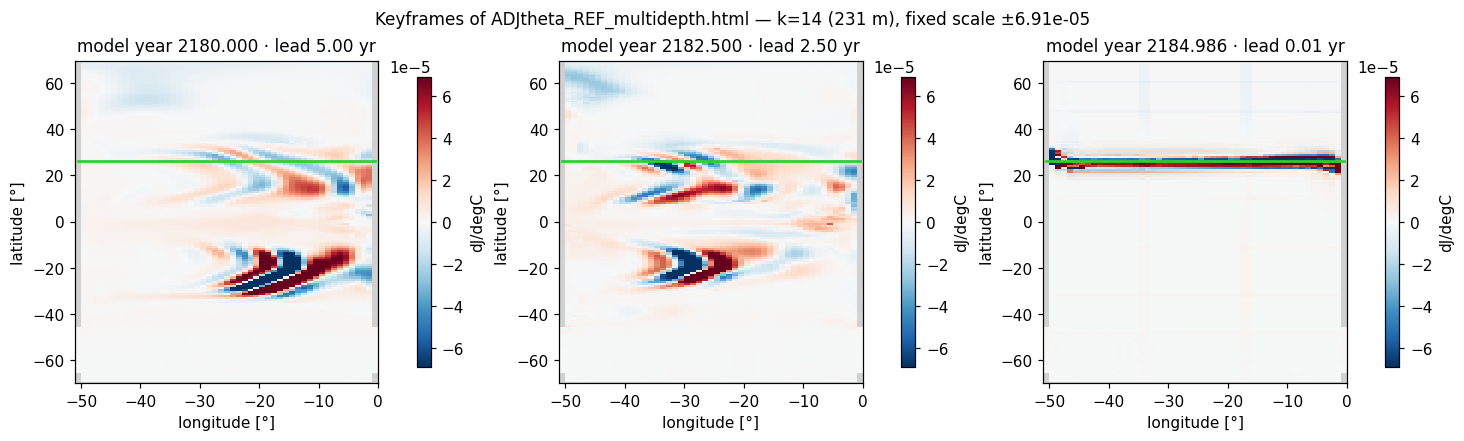

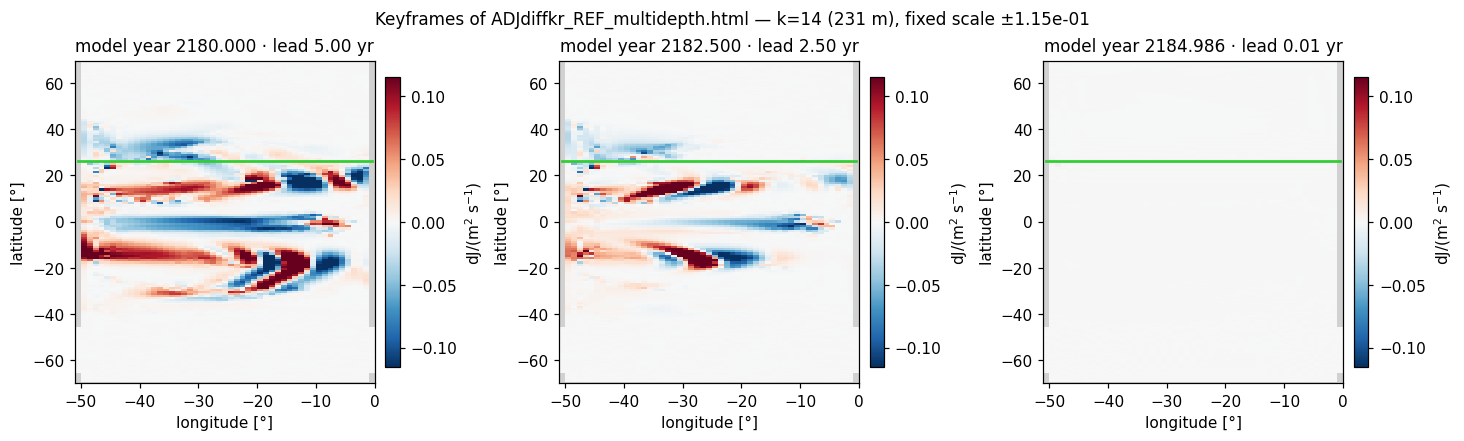

In [12]:
def key_iters(leads):
    return [ec.nearest_iter(ec.NITER_END - int(L * ec.STEPS_PER_YEAR))
            for L in leads]


KEY_LEADS = [5.0, 2.5, 0.014]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9), layout="constrained")
for ax, it in zip(axes, key_iters(KEY_LEADS)):
    draw_panel(ax, ec.read_adj("REF", "ADJtheta", it)[14], 14,
               VMAX_THETA[14], time_label(it), UNITS_TH)
fig.suptitle("Keyframes of ADJtheta_REF_multidepth.html — k=14 (231 m), "
             f"fixed scale ±{VMAX_THETA[14]:.2e}", fontsize=11)
ec.save_fig(fig, NB_STEM, "05_keyframes_ADJtheta_REF_multidepth")

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9), layout="constrained")
for ax, it in zip(axes, key_iters(KEY_LEADS)):
    draw_panel(ax, ec.read_adj("REF", "ADJdiffkr", it)[14], 14,
               VMAX_DIFFKR[14], time_label(it), UNITS_DK)
fig.suptitle("Keyframes of ADJdiffkr_REF_multidepth.html — k=14 (231 m), "
             f"fixed scale ±{VMAX_DIFFKR[14]:.2e}", fontsize=11)
ec.save_fig(fig, NB_STEM, "06_keyframes_ADJdiffkr_REF_multidepth")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/07_keyframes_REF_vs_M3_k14.png


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/08_keyframes_M5_blowup_log10.png


PosixPath('/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/08_keyframes_M5_blowup_log10.png')

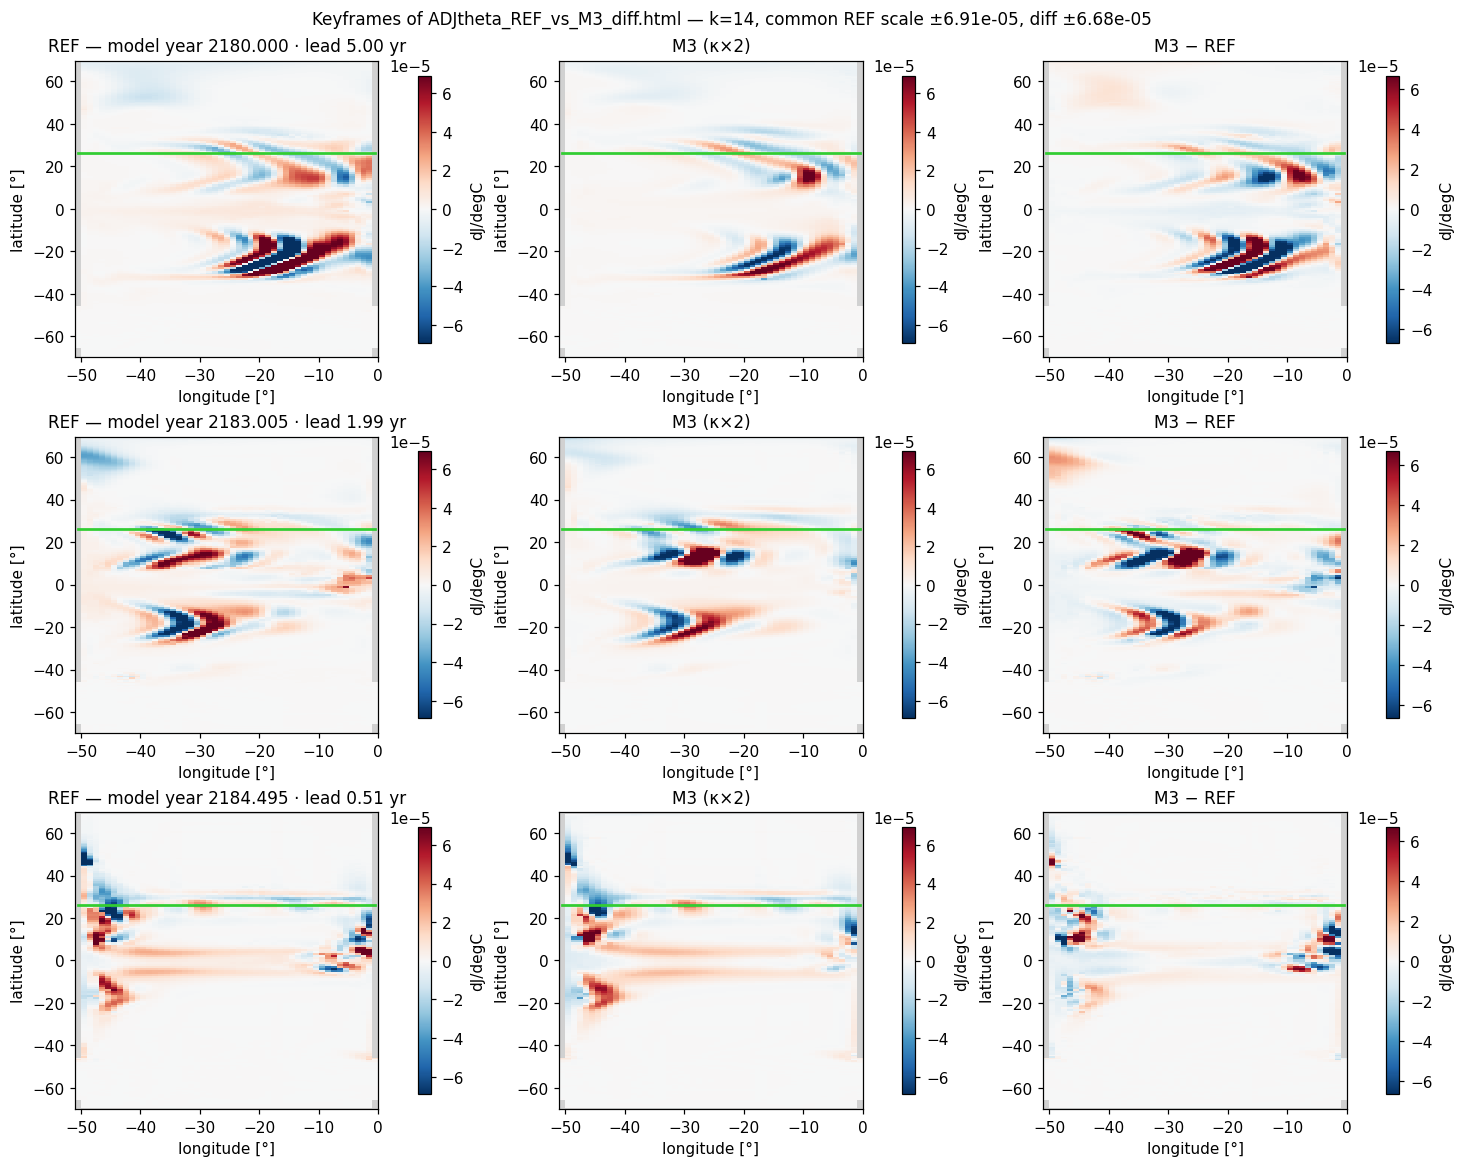

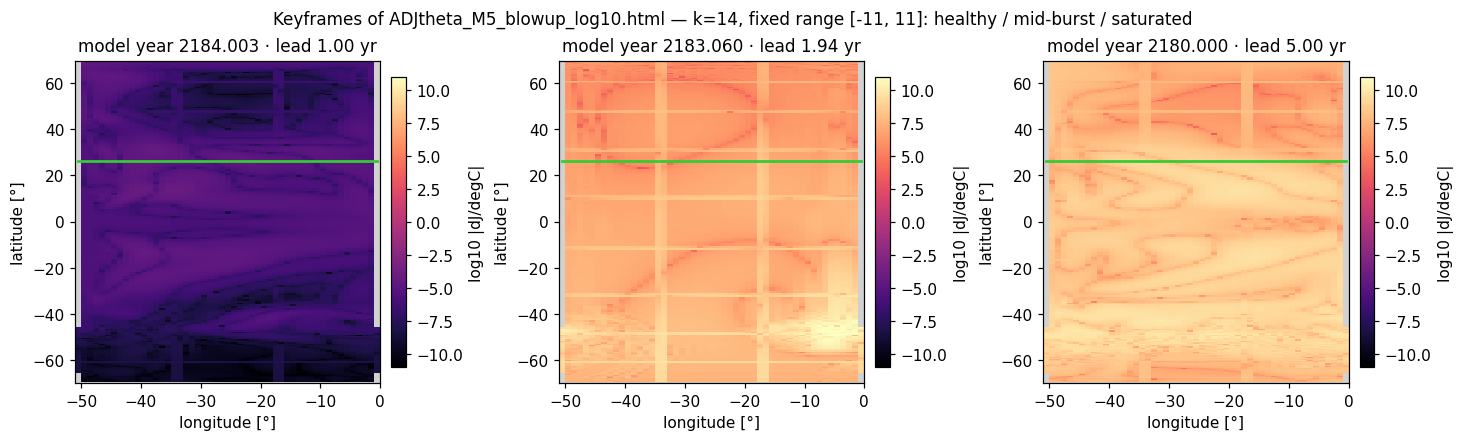

In [13]:
fig, rows_ax = plt.subplots(3, 3, figsize=(13.2, 10.5), layout="constrained")
for row, it in zip(rows_ax, key_iters([5.0, 2.0, 0.5])):
    aR = ec.read_adj("REF", "ADJtheta", it)[14]
    aM = ec.read_adj("M3", "ADJtheta", it)[14]
    draw_panel(row[0], aR, 14, VMAX_THETA[14],
               f"REF — {time_label(it)}", UNITS_TH)
    draw_panel(row[1], aM, 14, VMAX_THETA[14], "M3 (κ×2)", UNITS_TH)
    draw_panel(row[2], aM - aR, 14, VMAX_DIFF_M3, "M3 − REF", UNITS_TH)
fig.suptitle("Keyframes of ADJtheta_REF_vs_M3_diff.html — k=14, common REF "
             f"scale ±{VMAX_THETA[14]:.2e}, diff ±{VMAX_DIFF_M3:.2e}",
             fontsize=11)
ec.save_fig(fig, NB_STEM, "07_keyframes_REF_vs_M3_k14")

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9), layout="constrained")
for ax, it in zip(axes, key_iters([1.0, 1.94, 5.0])):
    a = np.abs(ec.read_adj("M5", "ADJtheta", it)[14])
    draw_panel(ax, np.log10(np.maximum(a, 1e-30)), 14, LOG_VMAX,
               time_label(it), f"log10 |{UNITS_TH}|", cmap="magma",
               diverging=False, vmin=LOG_VMIN)
fig.suptitle("Keyframes of ADJtheta_M5_blowup_log10.html — k=14, fixed range "
             f"[{LOG_VMIN:.0f}, {LOG_VMAX:.0f}]: healthy / mid-burst / "
             "saturated", fontsize=11)
ec.save_fig(fig, NB_STEM, "08_keyframes_M5_blowup_log10")

The four animation files live in
`/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations/`:

- `ADJtheta_REF_multidepth.html`
- `ADJdiffkr_REF_multidepth.html`
- `ADJtheta_REF_vs_M3_diff.html`
- `ADJtheta_M5_blowup_log10.html`

Each is a single self-contained file (sizes in §7's inventory) — open in any
browser, drag the slider or use ←/→, space toggles play, and the multidepth
pages have a depth dropdown.

## 6. Static montage — the spatial development of the M5 blow-up

For print/synthesis use: log₁₀|ADJtheta| of M5 at k=14 at leads 0.5, 1, 2, 3,
4, 5 yr (same fixed range as the animation). The montage brackets the burst
(departure lead 1.28 yr, catastrophic burst near lead 1.9); the code also
prints full-3-D seeding diagnostics — where the maximum lives and what
fraction of the wet volume exceeds |ADJtheta| = 10⁻³ (a value the healthy
field never reaches) — around the burst, plus each blown member's seed
location at its own departure lead.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations/09_M5_blowup_montage_k14.png

M5 seeding diagnostics (full 3-D ADJtheta):
  lead 1.803 yr: max |ADJtheta| = 4.89e-03 at k=34 (Z=-3727 m), -48.1°N -36.5°E; wet fraction >1e-3: 0.0005
  lead 1.858 yr: max |ADJtheta| = 1.59e+02 at k=33 (Z=-3223 m), -47.4°N -4.5°E; wet fraction >1e-3: 0.1191
  lead 1.940 yr: max |ADJtheta| = 6.87e+14 at k=33 (Z=-3223 m), -48.1°N -5.5°E; wet fraction >1e-3: 1.0000

Seed location of each blown member at its ADJtheta departure lead:
  M1 (κ×0.25, lead 2.55 yr): max at k=29 (Z=-1844 m), -37.9°N -44.5°E
  M4 (κ×4, lead 0.72 yr): max at k=1 (Z=-15 m), -48.1°N -50.5°E
  M5 (κ×8, lead 1.28 yr): max at k=32 (Z=-2795 m), -51.3°N -38.5°E
  M7 (κ×32, lead 0.36 yr): max at k=31 (Z=-2429 m), -47.4°N -48.5°E


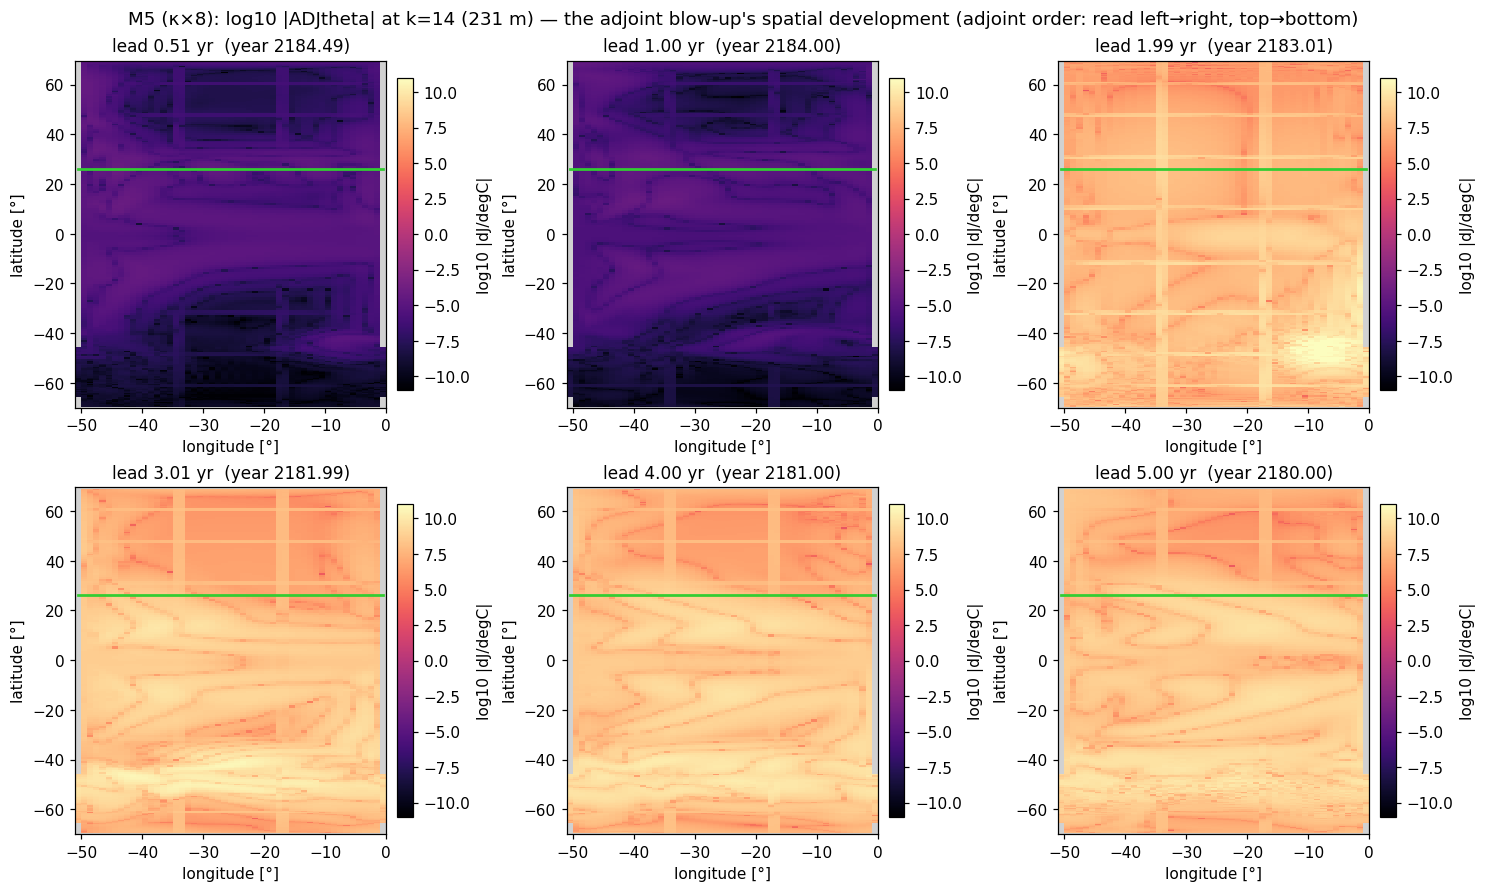

In [14]:
MONT_LEADS = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
fig, axes = plt.subplots(2, 3, figsize=(13.4, 8.0), layout="constrained")
for ax, L in zip(axes.flat, MONT_LEADS):
    it = ec.nearest_iter(ec.NITER_END - int(L * ec.STEPS_PER_YEAR))
    a = np.abs(ec.read_adj("M5", "ADJtheta", it)[14])
    draw_panel(ax, np.log10(np.maximum(a, 1e-30)), 14, LOG_VMAX,
               f"lead {ec.lead_years(it):.2f} yr  (year "
               f"{ec.model_year(it):.2f})", f"log10 |{UNITS_TH}|",
               cmap="magma", diverging=False, vmin=LOG_VMIN)
fig.suptitle("M5 (κ×8): log10 |ADJtheta| at k=14 (231 m) — the adjoint "
             "blow-up's spatial development (adjoint order: read left→right, "
             "top→bottom)", fontsize=12)
ec.save_fig(fig, NB_STEM, "09_M5_blowup_montage_k14")

wet3 = g["wetC"]
print("\nM5 seeding diagnostics (full 3-D ADJtheta):")
for L in [1.80, 1.86, 1.94]:
    it = ec.nearest_iter(ec.NITER_END - int(L * ec.STEPS_PER_YEAR))
    af = np.abs(np.where(wet3, ec.read_adj("M5", "ADJtheta", it), 0.0))
    af[~np.isfinite(af)] = 0.0
    k, j, i = np.unravel_index(np.argmax(af), af.shape)
    frac = (af[wet3] > 1e-3).mean()
    print(f"  lead {ec.lead_years(it):.3f} yr: max |ADJtheta| = "
          f"{af[k, j, i]:.2e} at k={k} (Z={g['Z'][k]:.0f} m), "
          f"{g['YC'][j, i]:.1f}°N {g['XC'][j, i]:.1f}°E; "
          f"wet fraction >1e-3: {frac:.4f}")

print("\nSeed location of each blown member at its ADJtheta departure lead:")
for mem in BLOWN:
    it = ec.nearest_iter(ec.NITER_END
                         - int(DEP_LEAD[mem] * ec.STEPS_PER_YEAR))
    af = np.abs(np.where(wet3, ec.read_adj(mem, "ADJtheta", it), 0.0))
    af[~np.isfinite(af)] = 0.0
    k, j, i = np.unravel_index(np.argmax(af), af.shape)
    print(f"  {mem} (κ×{ec.RUNS[mem]['factor']:g}, lead "
          f"{ec.lead_years(it):.2f} yr): max at k={k} "
          f"(Z={g['Z'][k]:.0f} m), {g['YC'][j, i]:.1f}°N "
          f"{g['XC'][j, i]:.1f}°E")

### Where the instability seeds

- **M5's blow-up seeds in the deep Southern Ocean, far from the cost
  section.** At lead 1.80 yr the field is healthy except one localised deep
  anomaly (max 4.9×10⁻³ at Z ≈ −3727 m, 48°S — 0.05 % of the wet volume
  above 10⁻³); 20 model days later (lead 1.86) the maximum is ~10² and 12 %
  of the volume is involved; by lead 1.94 **every wet cell** exceeds 10⁻³
  and the maximum is ~7×10¹⁴. Seed → domain-filling in ≈ 50 model days,
  matching the ~1-day burst e-fold time of §2.
- All four blown members' amplitude maxima at their departure leads sit in
  the **Southern Ocean channel sector** (38–51°S), three of them at abyssal
  levels (M1 k=29/1844 m, M7 k=31/2429 m, M5 k=32/2795 m — M5's pre-burst
  anomaly reaches k=34/3727 m) and M4 at the surface (k=1, 48°S) — nowhere
  near the 26°N cost section. The linearised instability lives in the members'
  altered deep/Southern-Ocean stratification, where the *physical*
  sensitivity signal is tiny; once seeded it overwhelms the whole domain
  within weeks (notebook 03's "domain-filling by lead 5 yr" anatomy).
- In the k=14 montage the leads 0.5 and 1.0 panels show the healthy phase
  (all values in the dark half of the fixed log scale, ~10⁻¹⁰–10⁻⁴);
  every panel from lead 2 on is saturated noise, brightest in the Southern
  Ocean — the transition happens entirely between the lead-1 and lead-2
  panels, and the animation (10-d cadence) localises it to lead ≈ 1.8–1.9 yr.

In [15]:
inv = pd.DataFrame(ANIM_INFO)
csvp = ec.STATS_ROOT / "06_animation_inventory.csv"
inv.to_csv(csvp, index=False)
print(f"saved {csvp}\n")
print("Animation inventory:")
print(inv.to_string(index=False))
print(f"\ntotal animation payload: {inv['size_MB'].sum():.1f} MB "
      f"(all in {ec.ANIM_ROOT})")

figs = sorted((ec.FIG_ROOT / NB_STEM).glob("*.png"))
print(f"\n{len(figs)} figures in {ec.FIG_ROOT / NB_STEM}:")
for f in figs:
    print(f"  {f.name}  ({f.stat().st_size / 1e3:.0f} kB)")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/06_animation_inventory.csv

Animation inventory:
                         file  size_MB  frames  depth_groups                                                    shows
 ADJtheta_REF_multidepth.html     23.1     183             3       REF sensitivity to theta, depth selector k=2/14/24
ADJdiffkr_REF_multidepth.html     21.7     183             3 REF sensitivity to kappa_v (surrogate target), k=2/14/24
 ADJtheta_REF_vs_M3_diff.html     15.9     183             1              REF | M3 | M3-REF at k=14, common REF scale
ADJtheta_M5_blowup_log10.html      9.4     183             1          M5 blow-up, log10|ADJtheta| k=14, adjoint order

total animation payload: 70.1 MB (all in /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations)

9 figures in /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/06_time_evolution_and_animations:
  01_rms_vs_lead_3d.png  (378 kB)
 

## 7. Summary

**Amplitude evolution (§2).** Four of the seven member adjoints blow up, in
an order unrelated to κ: departure leads 0.36 yr (M7, 32×), 0.72 yr (M4,
4×), 1.28 yr (M5, 8×), 2.56 yr (M1, 0.25×); M2 (0.5×), M3 (2×) and M6 (16×)
never depart. Growth is episodic — plateaus punctuated by bursts with e-fold
times of 1.0–3.2 days (divergence-phase fit e-folds 9–133 d, mostly with poor
R² because of the staircase shape). The blow-up is a property of the whole
co-state (2-D forcing sensitivities depart within ~0.5 yr of the 3-D
fields), and it is an instability of the *linearised dynamics around each
member's own background trajectory* — the forward runs, and fc, are healthy
in all nine cases. The plain (viscFacInAd = 1) build was used throughout;
the repo's adjViscBoost variant is the designated stabiliser for exactly
this failure mode.

**Structure evolution (§3).** All members track REF at short leads (corr
0.92–1.00 at 5 d). Sustained corr ≥ 0.8 windows are 30–140 d for *everyone*
(the early drop is mostly the physical κ signal emerging); sustained corr ≥
0.5 separates the regimes — stable members never cross it, blown members
cross it within ~10 d of their RMS departure. Usable training windows for a
surrogate are bounded by *validity* (departure leads: 130/265/470/935 d for
M7/M4/M5/M1), not by similarity to REF.

**Finiteness (§4).** Only M4 overflows: first inf/NaN at lead 2.91–2.95 yr,
~2.2 yr after its RMS departure; by lead 5 yr ADJempmr is ~100 % non-finite
while ADJtheta keeps 63 % finite cells.

**Seeding (§6).** All four blow-ups seed in the Southern Ocean channel
sector (38–51°S), three at abyssal depths; M5 goes from one deep seed point
to a domain-filling instability in ≈ 50 model days.

**Animation inventory** (all in
`/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/animations/`,
sizes as printed above):

| file | shows | frames | size |
| --- | --- | --- | --- |
| `ADJtheta_REF_multidepth.html` | REF θ-sensitivity, depth selector k=2/14/24 | 183 × 3 | 23.1 MB |
| `ADJdiffkr_REF_multidepth.html` | REF κ_v-sensitivity (surrogate target), k=2/14/24 | 183 × 3 | 21.7 MB |
| `ADJtheta_REF_vs_M3_diff.html` | REF \| M3 \| M3−REF at k=14, common scale | 183 | 15.9 MB |
| `ADJtheta_M5_blowup_log10.html` | M5 blow-up, log₁₀\|ADJtheta\| k=14, adjoint order | 183 | 9.4 MB |

Next: notebook 07 synthesises these results with 01–05 into the answer to
the master plan's Part I question and its surrogate implications.